<a href="https://colab.research.google.com/github/But-Vladyslava/Machine-Learning-Uni-/blob/main/%D0%9B%D0%912_1_%D0%91%D1%83%D1%82_3_12_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Бут, група 3-12
---



# Завдання 1

**Була присутня на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [43]:
import io
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text
tables = pd.read_html(io.StringIO(html), match="IMF")
df = tables[0]

In [44]:
df.head(5)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [45]:
df.shape

(222, 4)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [46]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

In [47]:
df = df.drop(columns=['United Nations (2024)[7]'])

display(df.head())
print(df.columns)
df

,Country/Territory,IMF (2026)[1],World Bank (2025)[6]
0,World,126295331,118350166
1,United States,32383920,30769700
2,China[n 1],20851593,19498039
3,Germany,5452858,5050923
4,Japan,4379253,4435163


Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]'], dtype='object')


,Country/Territory,IMF (2026)[1],World Bank (2025)[6]
0,World,126295331,118350166
1,United States,32383920,30769700
2,China[n 1],20851593,19498039
3,Germany,5452858,5050923
4,Japan,4379253,4435163
...,...,...,...
217,Palau,377,345
218,Marshall Islands,342,308
219,Nauru,196,176
220,Montserrat,—N/a,—N/a


In [52]:
df.head(35)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6]
0,World,126295331,118350166
1,United States,32383920,30769700
2,China[n 1],20851593,19498039
3,Germany,5452858,5050923
4,Japan,4379253,4435163
5,United Kingdom,4264794,4002588
6,India,4153191,3956067
7,France,3596094,3366316
8,Italy,2738164,2551557
9,Russia,2656452,2561310


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [82]:
import io
import numpy as np
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

In [83]:
html = requests.get(url, headers=headers, timeout=30).text
tables = pd.read_html(io.StringIO(html), match="IMF")
df = tables[0]

In [84]:
df = df.replace(["—", "—N/a", "— N/a"], np.nan)

In [85]:
for col in df.columns:
  if col != "Country/Territory":
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"\[.*?\]", "", regex=True)
        .str.replace(",", "", regex=True)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")


print("Кількість пропущених значень:")
print(df.isnull().sum())

Кількість пропущених значень:
Country/Territory            0
IMF (2026)[1]               31
World Bank (2025)[6]        35
United Nations (2024)[7]     9
dtype: int64


In [129]:
df = df.fillna(df.mean(numeric_only=True))

pd.options.display.float_format = "{:.2f}".format
df.head(35)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],Difference,Std
0,World,126295331.00,118350166.00,111565144.00,7945165.00,51393241.37
1,United States,32383920.00,30769700.00,29298000.00,1614220.00,13461032.07
2,China[n 1],20851593.00,19498039.00,18743802.00,1353554.00,8505579.27
3,Germany,5452858.00,5050923.00,4659929.00,401935.00,2173545.18
4,Japan,4379253.00,4435163.00,4026211.00,55910.00,1925099.72
5,United Kingdom,4264794.00,4002588.00,3685881.00,262206.00,1728851.94
6,India,4153191.00,3956067.00,3952244.00,197124.00,1757120.09
7,France,3596094.00,3366316.00,3160443.00,229778.00,1459770.93
8,Italy,2738164.00,2551557.00,2380825.00,186607.00,1103105.04
9,Russia,2656452.00,2561310.00,2173386.00,95142.00,1097210.99


5. Ще раз вивести датасет

In [88]:
df

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331.00,118350166.00,111565144.00
1,United States,32383920.00,30769700.00,29298000.00
2,China[n 1],20851593.00,19498039.00,18743802.00
3,Germany,5452858.00,5050923.00,4659929.00
4,Japan,4379253.00,4435163.00,4026211.00
...,...,...,...,...
217,Palau,377.00,345.00,310.00
218,Marshall Islands,342.00,308.00,281.00
219,Nauru,196.00,176.00,187.00
220,Montserrat,1319229.25,1255590.42,81.00


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [90]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 0


In [91]:
df = df.drop_duplicates()

In [92]:
df.shape

(222, 4)

7.	Вивести описову статистику датасету describe()

In [93]:
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
count,222.00,222.00,222.00
mean,1319229.25,1255590.42,1043818.22
std,8838875.59,8288460.69,7830341.06
min,65.00,57.00,56.00
25%,19323.75,20034.00,9170.75
50%,103974.50,99863.50,43224.50
75%,772667.75,1041520.50,304854.50
max,126295331.00,118350166.00,111565144.00


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [95]:
df["Difference"] = (df["IMF (2026)[1]"] - df["World Bank (2025)[6]"]).abs()

df_sorted = df.sort_values(by="Difference", ascending=False)

display(
    df_sorted[
        ["Country/Territory", "IMF (2026)[1]", "World Bank (2025)[6]", "Difference"]
    ].head(10)
)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],Difference
0,World,126295331.00,118350166.00,7945165.00
1,United States,32383920.00,30769700.00,1614220.00
2,China[n 1],20851593.00,19498039.00,1353554.00
197,Sint Maarten,1319229.25,1888.00,1317341.25
146,Palestine[n 11][n 12],1319229.25,17167.00,1302062.25
192,San Marino,2417.00,1255590.42,1253173.42
179,Aruba,4671.00,1255590.42,1250919.42
172,South Sudan,6069.00,1255590.42,1249521.42
168,Yemen,7435.00,1255590.42,1248155.42
159,Liechtenstein,9442.00,1255590.42,1246148.42


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [96]:
correlation_matrix = df.select_dtypes(include=["number"]).corr()

In [97]:
display(correlation_matrix)

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],Difference
IMF (2026)[1],1.00,1.00,1.00,0.91
World Bank (2025)[6],1.00,1.00,1.00,0.91
United Nations (2024)[7],1.00,1.00,1.00,0.90
Difference,0.91,0.91,0.90,1.00


Обчислити середнє значення за стовпцями

In [98]:
numeric_df = df.select_dtypes(include="number")

In [99]:
means = numeric_df.mean()

In [100]:
display(means)

,0
IMF (2026)[1],1319229.25
World Bank (2025)[6],1255590.42
United Nations (2024)[7],1043818.22
Difference,140563.67


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [106]:
df["Std"] = df.select_dtypes(include="number").std(axis=1)
df_sorted_std = df.sort_values(by="Std", ascending=False)
display(df_sorted_std[["Country/Territory", "Std"]].head(10))

,Country/Territory,Std
0,World,51393241.37
1,United States,13461032.07
2,China[n 1],8505579.27
3,Germany,2173545.18
4,Japan,1925099.72
6,India,1757120.09
5,United Kingdom,1728851.94
7,France,1459770.93
8,Italy,1103105.04
9,Russia,1097210.99


Яка країна має найвищу варіативність у показниках між роками?

United States

12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [109]:
cols = ["IMF (2026)[1]", "World Bank (2025)[6]", "United Nations (2024)[7]"]
df_countries = df[df["Country/Territory"] != "World"]
res = pd.DataFrame({c: [df_countries.loc[df_countries[c].idxmax(), "Country/Territory"], df_countries.loc[df_countries[c].idxmin(), "Country/Territory"]] for c in cols}, index=["Max", "Min"])
display(res)

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
Max,United States,United States,United States
Min,Tuvalu,Tuvalu,Tuvalu


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

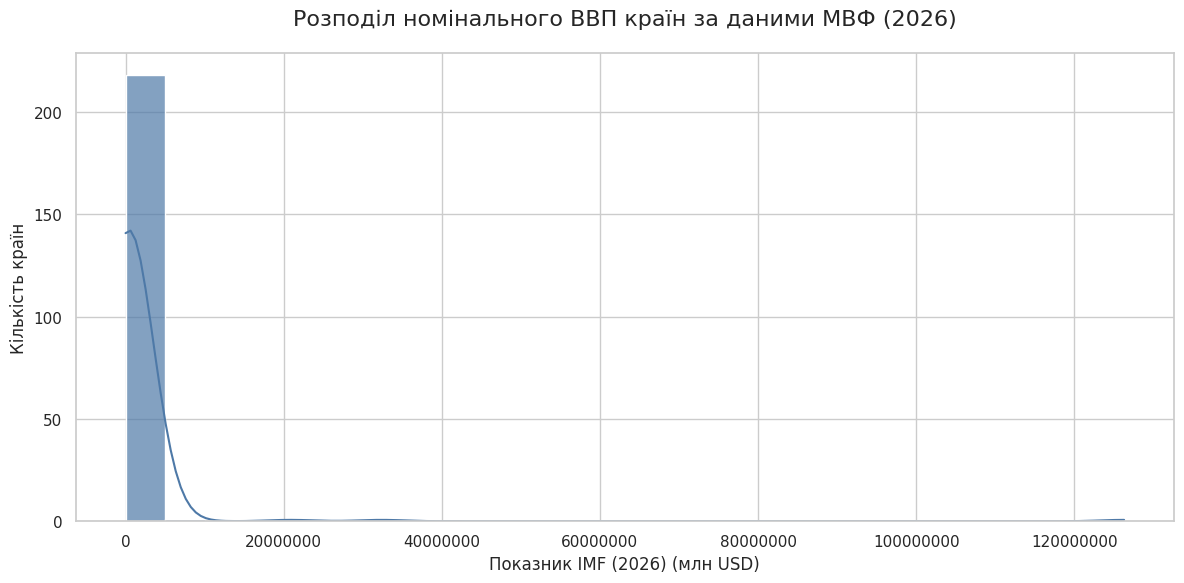

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

hist_plot = sns.histplot(data=df, x='IMF (2026)[1]', bins=25, kde=True,
                         color='#4e79a7', edgecolor='white', alpha=0.7)

plt.title('Розподіл номінального ВВП країн за даними МВФ (2026)', fontsize=16, pad=20)
plt.xlabel('Показник IMF (2026) (млн USD)', fontsize=12)
plt.ylabel('Кількість країн', fontsize=12)

from matplotlib.ticker import ScalarFormatter
hist_plot.xaxis.set_major_formatter(ScalarFormatter())
hist_plot.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()


Розподіл має правосторонню асиметрію, оскільки більшість країн зосереджена в області низьких і середніх показників

In [120]:
threshold = df['IMF (2026)[1]'].quantile(0.97)
outliers = df[df['IMF (2026)[1]'] > threshold][['Country/Territory', 'IMF (2026)[1]']]
print("\nКраїни, що виділяються (найвищі показники - верхні 3%):")
display(outliers.sort_values(by='IMF (2026)[1]', ascending=False))


Країни, що виділяються (найвищі показники - верхні 3%):


,Country/Territory,IMF (2026)[1]
0,World,126295331.00
1,United States,32383920.00
2,China[n 1],20851593.00
3,Germany,5452858.00
4,Japan,4379253.00
5,United Kingdom,4264794.00
6,India,4153191.00


14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [121]:
cols = ["IMF (2026)[1]", "World Bank (2025)[6]", "United Nations (2024)[7]"]
df_shares = df.copy()
for c in cols:
    df_shares[c + "_share"] = df_shares[c] / df_shares[c].sum() * 100

display(df_shares[["Country/Territory"] + [c + "_share" for c in cols]].head(10))

,Country/Territory,IMF (2026)[1]_share,World Bank (2025)[6]_share,United Nations (2024)[7]_share
0,World,43.12,42.46,48.14
1,United States,11.06,11.04,12.64
2,China[n 1],7.12,7.00,8.09
3,Germany,1.86,1.81,2.01
4,Japan,1.50,1.59,1.74
5,United Kingdom,1.46,1.44,1.59
6,India,1.42,1.42,1.71
7,France,1.23,1.21,1.36
8,Italy,0.93,0.92,1.03
9,Russia,0.91,0.92,0.94


Частки головних країн усюди залишаються стабільно високими

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

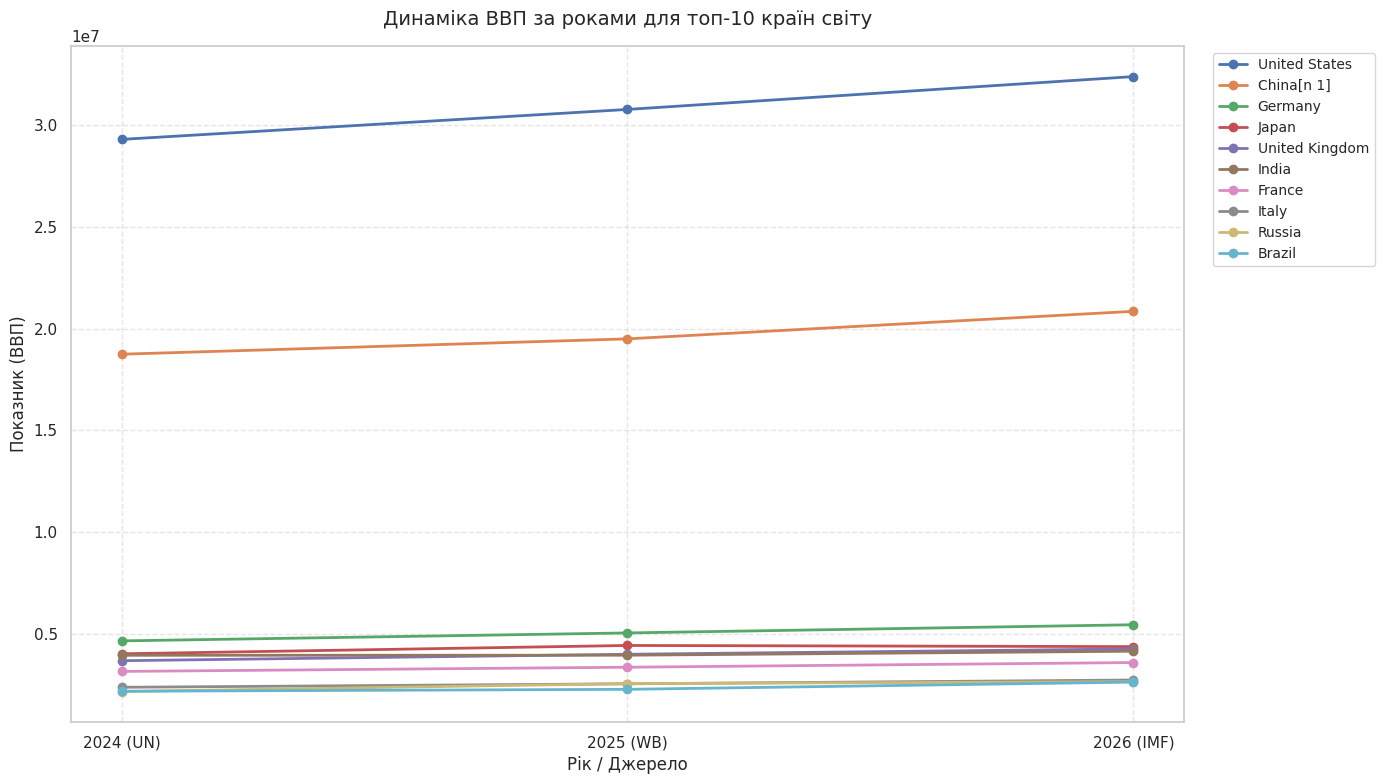

In [128]:
import matplotlib.pyplot as plt

years = ['United Nations (2024)[7]', 'World Bank (2025)[6]', 'IMF (2026)[1]']
year_labels = ['2024 (UN)', '2025 (WB)', '2026 (IMF)']

plt.figure(figsize=(14, 8))

top_countries = df[df['Country/Territory'] != 'World'].head(10)

for idx, row in top_countries.iterrows():
    plt.plot(year_labels, row[years].values, marker='o', linewidth=2, label=row['Country/Territory'])

plt.title('Динаміка ВВП за роками для топ-10 країн світу', fontsize=14, pad=15)
plt.xlabel('Рік / Джерело', fontsize=12)
plt.ylabel('Показник (ВВП)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

для наочності обрала топ-10 країн. Усі вони показують стабільне зростання показників з року в рік, демонструючи загальне збільшення обсягів ВВП за оцінками міжнародних організацій на 2024–2026 роки без жодних ознак спаду.